# Проект: Проверка гипотез в Python и результаты А/B-теста

## Часть 1. Проверка гипотезы в Python и составление аналитической записки

* Автор: Филимонова Мария
* Дата: 16.04

### Цели и задачи проекта

**Цель:** Проверить статистическую гипотезу о наличии различий в среднем времени чтения и прослушивания книг между пользователями из Москвы и Санкт‑Петербурга

**Задачи:**

- Загрузить необходимые данные

- Разделить данные на группы

- Проверить на наличие выбросов

- Провести t-тест Уэлча

- Интерпритация результатов

### Описание данных

В первой части проекта будет использован датасет `yandex_knigi_data` с таким описанием:

- `Unnamed: 0` - технический индекс строки
- `city` - название города 
- `puid` - идентификатор пользователя
- `hours` - суммарное время активности пользователя

Во второй части проета будут использованы два датасета.
Первый датасет - `participants`:

- `user_id` - идентификатор пользователя
- `group` - группа пользователя
- `ab_test` - название теста
- `device` - устройство, с которого происходила регистрация

И датасет - `events` с таким описанием:

- `user_id` - идентификатор пользователя
- `event_dt` - дата и время события
- `event_name` - тип события
- `details` - дополнительные данные о событии

### Содержимое проекта

1. Проверка гипотезы в Python и составление аналитической записки
    
    1.1. Загрузка данных и знакомство с ними

    1.2. Проверка гипотезы в Python

    1.3. Аналитическая записка

2. Анализ результатов A/B-тестирования

    1. Цель исследования

    2. Загрузка данных и знакомство с ними

    3.  Оценка корректности проведения теста

        3.1. Выделение пользователей теста

        3.2. Анализ данных о пользовательской активности по таблице `ab_test_events`

    4. Оценка результатов A/B-тестирования

### 1.1. Загрузка данных и знакомство с ними

In [20]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, norm

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [21]:
# Выгружаем данные в переменную yandex_knigi_data
try:
    yandex_knigi_data = pd.read_csv('/datasets/yandex_knigi_data.csv')
except FileNotFoundError:
    yandex_knigi_data = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс книги/yandex_knigi_data.csv')

Познакомимся с данными датасета `yandex_knigi_data.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [22]:
# Выводим первые строки датафрейма на экран
yandex_knigi_data.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [23]:
# Выводим информацию о датафрейме
yandex_knigi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Датасет `yandex_knigi_data.csv` содержит 4 столбца и 8784 строки, в котором представлена информация о пользователях из Москвы и Санкт-Петербурга c суммой часов их активности

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Данные имеют корректный тип данных

- Пропусков в данном датасет нет

Удалим столбец `Unnamed: 0`

In [24]:
# Удаления столбца Unnamed: 0
yandex_knigi_data = yandex_knigi_data.drop('Unnamed: 0', axis=1)

In [25]:
# Проверим на полные дубликаты
yandex_knigi_data.duplicated().sum()

np.int64(0)

В датафрейме `yandex_knigi_data.csv` нет полных дубликатов

Проверим уникальность идентификаторов

In [26]:
# Проверка уникальности идентификаторов
print(f"Дубликатов puid: {yandex_knigi_data['puid'].duplicated().sum()}")

Дубликатов puid: 244


При проверке уникальности идентификаторов было обнаружено 244 дубликата. 

Данные дубликаты стоит удалить

In [27]:
# Удаляем дубликаты, оставляя первое вхождение для каждого puid
yandex_knigi_new_data = yandex_knigi_data.drop_duplicates(subset='puid', keep='first')

Проверим данные на аномалии и выбросы

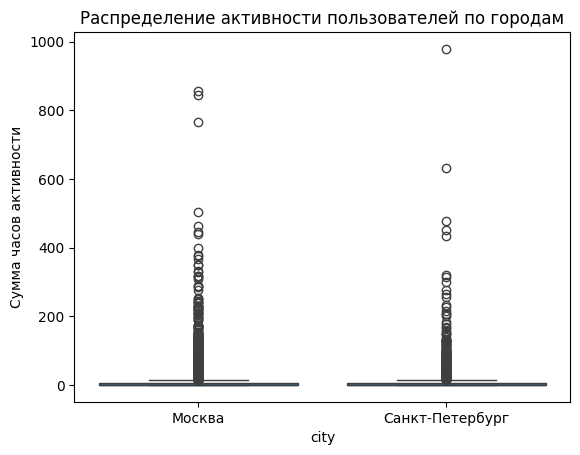

In [28]:
# Создаем график boxplot
sns.boxplot(x='city', y='hours', data=yandex_knigi_new_data)

# Настраиваем оформление графика
plt.title('Распределение активности пользователей по городам')
plt.ylabel('Сумма часов активности')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В обоих городах присутствуют пользователи с аномально высокой активностью, которые заметно выделяются на фоне остальных

In [29]:
# Для каждого города выбираем столбец hours
group_msc = yandex_knigi_new_data[yandex_knigi_new_data['city'] == 'Москва']['hours']
group_spb = yandex_knigi_new_data[yandex_knigi_new_data['city'] == 'Санкт-Петербург']['hours']

In [30]:
# Создаем функцию для расчета IQR
def iqr(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(name)
    print(f'Q1: {Q1:,.2f}')
    print(f'Q3: {Q3:,.2f}')
    print(f'IQR: {IQR:,.2f}')
    print(f'Нижняя граница выбросов: {lower_bound:,.2f}')
    print(f'Верхняя граница выбросов: {upper_bound:,.2f}')

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f'Количество выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)')
    print()

    return lower_bound, upper_bound

lower_msc, upper_msc = iqr(group_msc, 'Москва')
lower_spb, upper_spb = iqr(group_spb, 'Санкт-Петербург')

Москва
Q1: 0.06
Q3: 5.94
IQR: 5.88
Нижняя граница выбросов: -8.76
Верхняя граница выбросов: 14.76
Количество выбросов: 900 (14.44%)

Санкт-Петербург
Q1: 0.06
Q3: 6.14
IQR: 6.08
Нижняя граница выбросов: -9.06
Верхняя граница выбросов: 15.26
Количество выбросов: 346 (15.00%)



In [31]:
# Удаляем выбросы
group_msc_clean = group_msc[(group_msc >= lower_msc) & (group_msc <= upper_msc)]
group_spb_clean = group_spb[(group_spb >= lower_spb) & (group_spb <= upper_spb)]

In [32]:
# Вычисляем, от какого процента данных мы избавились
percent_clean = 100 - (100 * len(yandex_knigi_new_data) / len(yandex_knigi_data))

# выводим результат
print(f'Избавились от {percent_clean:.2f}% данных')

Избавились от 2.78% данных


### 1.2. Проверка гипотезы в Python

**Гипотеза:** пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

**H<sub>0</sub> (нулевая гипотеза):** Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

**H<sub>1</sub> (альтернативная гипотеза):** Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [33]:
# Задаем уровень значимости
alpha = 0.05

# Проводим t-тест Уэлча
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    group_spb_clean,
    group_msc_clean, 
    equal_var=False,
    alternative='greater' 
)

# Выводим значения
print(f'p-value = {p_value_welch_ttest:.2f}')
print(f'stat_ttest = {stat_welch_ttest:.2f}')


p-value = 0.64
stat_ttest = -0.37


In [34]:
# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if p_value_welch_ttest > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Нет достаточных оснований для отклонения нулевой гипотезы


### 1.3. Аналитическая записка

**Аналитическая записка**

1. Выбранный тип теста и уровень статистической значимости

    - Был выбран t-тест Уэлча, так как он не предполагает равенства дисперсий в группах

    - Уровень значимости равен 0.05 (5%)

2. t-статистика = -0,37

    pvalue = 0,64 (Значение pvalue больше значения alpha)

3. В результате проведени t-теста Уэлча, можно сделать вывод, что нет достаточных оснований для отклонения нулевой гипотезы

4. - Различия в генеральных совокупностях нет

    - Нарушения в дизайне сбора данных

## Часть 2. Анализ результатов A/B-тестирования

### 1. Цель исследования

1. Загрузить данные

2. Проверить корректность проведения A/B-теста

3. Проанализировать полученные результаты

### 2. Загрузка данных и знакомство с ними

In [35]:
# Выгружаем данные в переменную participants
try:
    participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
except FileNotFoundError:
    participants = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс книги/ab_test_participants.csv')

In [36]:
# Выгружаем данные в переменную events
try:
    events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)
except FileNotFoundError:
    participants = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс книги/ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)


In [37]:
# Выводим первые строки датафрейма на экран
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [38]:
# Выводим информацию о датафрейме
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


Датасет `ab_test_participants.csv` содержит 4 столбца и 14525 строк, в котором представлена информация об участниках теста

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Данные имеют корректный тип данных

- Пропусков в данном датасет нет

In [39]:
# Выводим первые строки датафрейма на экран
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [40]:
# Выводим информацию о датафрейме
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Архив `ab_test_events.zip` содержит один `csv` файл, в котором собраны события 2020 года. Данный `csv` файл содержит 4 столбца и 787286 строк:

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных имеют корректный тип данных, кроме столбца `event_dt`. Его стоит привести к типу даты и времени

- Стобец `user_id` содержит значения `GLOBAL`, их стоит удалить

- Пропусков содержаться в столбце `details`. Это допустимо, так как не у всех событий есть дополнительные данные

In [41]:
# Удаляем значения GLOBAL из столбца user_id из датафрейма events
events = events[events['user_id'] != 'GLOBAL']

In [42]:
# Проверим на полные дубликаты датафрейм participants
participants.duplicated().sum()

np.int64(0)

В датасете `participants` нет полных дубликатов

Также проверим наличие полных дубликатов в датасете `events`

In [43]:
# Проверим на полные дубликаты датафрейм events
events.duplicated().sum()

np.int64(35473)

Данный датасет содержит 36318 полных дубликатов. Их стоит удалить

In [44]:
# Удаляем полные дубликаты
events = events.drop_duplicates().reset_index(drop=True) 

### 3. Оценка корректности проведения теста

#### 3.1. Выделение пользователей теста

In [45]:
# Выделим пользователей теста interface_eu_test
test_df = participants[participants['ab_test'] == 'interface_eu_test'].copy()

# Выводим результат
print(f'Участников теста: {len(test_df)}')
print(test_df['group'].value_counts())

Участников теста: 10850
group
B    5467
A    5383
Name: count, dtype: int64


In [46]:
# Считаем уникальное количесво пользователей в группах A и B
test_df_A = test_df[test_df['group'] == 'A']['user_id'].nunique()
test_df_B = test_df[test_df['group'] == 'B']['user_id'].nunique()

# Выводим результат
test_df_A, test_df_B

(5383, 5467)

In [47]:
# Считаем процентное соотношение для групп A и B
percent_A = 100 * test_df[test_df['group'] == 'A']['user_id'].nunique() / test_df['user_id'].nunique()
percent_B = 100 * test_df[test_df['group'] == 'B']['user_id'].nunique() / test_df['user_id'].nunique()

# Выводим результат
percent_A, percent_B

(49.61290322580645, 50.38709677419355)

Расхождения в данных небольшие. Тем не менее стоит проверить пользователей, которые могли попасть в обе группы

In [48]:
# Выделяем идентификаторы для каждой группы
interface_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
recommender_users = participants[participants['ab_test'] == 'recommender_system_test']['user_id']

# Находим пользователей, которые попадали в обе группы
intersection = list(set(interface_users) & set(recommender_users))

# Выводим результат
print(f'Количество пересекающихся пользователей: {len(intersection)}')

Количество пересекающихся пользователей: 887


In [49]:
# Удалим пересекающихся пользователей
test_df_clean = test_df[~test_df['user_id'].isin(intersection)]
print(test_df_clean['group'].value_counts())

group
B    5011
A    4952
Name: count, dtype: int64


In [50]:
# Выделяем идентификаторы для каждой группы
group_a = participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'A')]['user_id']
group_b = participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'B')]['user_id']

# Находим пользователей, которые попадали в обе группы
intersection = list(set(group_a) & set(group_b))

# Выводим результат
print(f'Количество пересекающихся пользователей: {len(intersection)}')

Количество пересекающихся пользователей: 0


#### 3.2. Анализ данных о пользовательской активности по таблице `ab_test_events`

In [51]:
# Получаем список пользователей из теста interface_eu_teat
test_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id'].unique()

In [52]:
# Фильтруем события: оставляем только те, что связаны с пользователями
events_test = events[events['user_id'].isin(test_users)]

# Выводим результат 
print(f'Всего событий до фильтрации: {len(events)}')
print(f'Всего событий после фильтрации: {len(events_test)}')
print(f"Количество уникальных пользователей в отфильтрованных событиях: {events_test['user_id'].nunique()}")

Всего событий до фильтрации: 693318
Всего событий после фильтрации: 73545
Количество уникальных пользователей в отфильтрованных событиях: 10850


In [53]:
# Извлекаем данные о дате для каждого польозователя
reg_date = events_test[events_test['event_name'] == 'registration'][['user_id', 'event_dt']]

In [54]:
# Агрериуем данные о датах регистрации
reg_first = reg_date.groupby('user_id').agg(reg_dt = ('event_dt', 'min')).reset_index()

In [55]:
# Добавляем reg_dt к каждому событию пользователя
events_with_reg = events_test.merge(reg_first, on='user_id', how='left')

In [56]:
# Вычисляем разницу в днях между событием и регистрацией
events_with_reg['days_since_reg'] = (events_with_reg['event_dt'] - events_with_reg['reg_dt']).dt.total_seconds() / (3600 * 24)

# Оставляем только события, произошедшие в течение первых 7 дней (включительно)
events_7days = events_with_reg[events_with_reg['days_since_reg'] <= 7].copy()

# Выводим первые строки датафрейма на экран
events_7days.head()

,user_id,event_dt,event_name,details,reg_dt,days_since_reg
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.0


In [57]:
# Задаем параметры
alpha = 0.05 
beta = 0.2  
power = 1 - beta  
p = 0.3 
mde = 0.03  
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 
)

# Выводим результат
print(f'Необходимый размер выборки для каждой группы: {int(sample_size)}')

Необходимый размер выборки для каждой группы: 3761


In [58]:
# Из датафрейма participants извлекаем user_id, group
participants_df = participants[participants['ab_test'] == 'interface_eu_test'][['user_id', 'group']]

# К датафрейму events_7d_df присоединяем датафрейм participants_df
events_7d_df = events_7days.merge(participants_df, on='user_id', how='inner')

In [59]:
# Фильтруем события "покупка" и считаем уникальное количество покупателей по группам
purchases_7d = events_7d_df[events_7d_df['event_name'] == 'purchase']
buyers_by_gr = purchases_7d.groupby('group')['user_id'].nunique()

# Выводим результат
buyers_by_gr

group
A    1480
B    1600
Name: user_id, dtype: int64

In [60]:
# Считаем уникальное количество пользователей по группам
visitors_by_gr = events_7d_df.groupby('group')['user_id'].nunique()

# Выводим результат
visitors_by_gr

group
A    5383
B    5467
Name: user_id, dtype: int64

In [61]:
# Создаем датафрейм
result = pd.DataFrame({'Покупатели': buyers_by_gr, 'Посетители': visitors_by_gr})

# Выводим первые строки датафрейма
result.head()

,Покупатели,Посетители
group,,
A,1480,5383
B,1600,5467


**Вывод:**

- Сравнение числа посетителей и покупателей

    - Контрольная группа (A): 5383 посетителя, 1480 покупателей.

    - Тестовая группа (B): 5467 посетителей, 1600 покупателей.

    Абсолютное количество покупателей в группе B на 120 больше, чем в группе A.


### 4. Оценка результатов A/B-тестирования

**H<sub>0</sub> (нулевая гипотеза):** Конверсия в группы B не превышает конверсию в группе A на 3%

**H<sub>1</sub> (альтернативная гипотеза):** Конверсия в группе B выше, чем в группе A, как минимум на 3%

In [62]:
# Исходные данные
n_a = result.loc['A', 'Посетители']
m_a = result.loc['A', 'Покупатели']
n_b = result.loc['B', 'Посетители']
m_b = result.loc['B', 'Покупатели']

# Рассчитаем конверсии для каждой группы: A и B
p_a = m_a / n_a
p_b = m_b / n_b

# Условие нормального приближения (ожидаемое число успехов/неудач > 10)
if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10):
    print("Предпосылка о достаточном количестве данных выполняется.")

    # Задаем разницу конверсий
    delta_0 = 0.03

    # Расчитываем разницу конверсий
    p_c = p_b - p_a

    # Рассчитываем pooled-оценку
    p_pooled = (m_a + m_b) / (n_a + n_b)

    # Расчитываем стандартную ошибку
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b))

    # Расчитываем z-статистику
    stat_ztest = (p_c - delta_0) / se_pooled

    # Рассчитываем p-значение
    p_value_ztest = 1 - norm.cdf(stat_ztest)

    # Выводим результат
    print(f'\nКонверсия группы А: {p_a:.4f} ({p_a * 100:.2f}%)')
    print(f'Конверсия группы B: {p_b:.4f} ({p_b * 100:.2f}%)')
    print(f'Разница конверсий (B - A): {p_c * 100:.2f}%')
    print(f'Pooled SE = {se_pooled:.6f}')
    print(f'z-статистика = {stat_ztest:.4f}')
    print(f'p-value = {p_value_ztest:.4f}')
else:
    print("Предпосылка о достаточном количестве данных НЕ выполняется.")

Предпосылка о достаточном количестве данных выполняется.

Конверсия группы А: 0.2749 (27.49%)
Конверсия группы B: 0.2927 (29.27%)
Разница конверсий (B - A): 1.77%
Pooled SE = 0.008657
z-статистика = -1.4178
p-value = 0.9219


In [63]:
# Зададим уровень значимости
alpha = 0.05

# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if p_value_ztest > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Нет достаточных оснований для отклонения нулевой гипотезы


**Итоговый выод:**

- Краткая справка о проведенном анализе

    - При проведении проверки корректности теста было обнаружено 887 пользователей, которые участвовали в 2-х тестах. Данные пользователи были удалены

    - Период анализа составил первые 7 дней после регистрации каждого пользователя

    - В качестве метрики была использована конверсия

- Результаты конверсии

    - Разница конверсий составляет 1,77%

- В результате проведения z-теста, можно сделать вывод, что нет достаточных оснований для отклонения нулевой гипотезы

- Упрощение интерфейса привело к небольшому росту конверсии (+1.78%), но этот рост статистически значимо меньше требуемых 3 п.п.

- Рекомендации

    - Не внедрять новый интерфейс

    - Пересмотреть дизайн эксперимента, чтобы избежать пересечения с другими тестами

    - Провести повторный A/B-тест